In [1]:
import torch
from torchvision.io import decode_image, ImageReadMode
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights, fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt

from b200_lego_dataset import load_val_set
from presets import get_transforms

device = torch.device('cpu')

### Load Model

In [3]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

num_classes = 201
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# 3. Load your trained weights
checkpoint = torch.load('model/model_epoch_20.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

model.to(device)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

Inference

In [4]:
val_set = load_val_set()

In [5]:
image, target = val_set[0]
image = image.to(device)
targets = {k : v.to(device) if isinstance(v, torch.Tensor) else v for k,v in target.items()}

In [14]:
def perform_inference(image_path, model, device, threshold=0.2):
    # 1. Load and Preprocess the image
    img = decode_image(image_path, mode=ImageReadMode.RGB)
    transform = get_transforms(is_train=False)
    img_tensor = transform(img).to(device)

    # 2. Run Inference
    with torch.no_grad():
        # Model expects a list of images
        prediction = model([img_tensor])

    pred = prediction[0]

    boxes = pred['boxes'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()
    scores = pred['scores'].cpu().numpy()

    mask = scores > threshold
    boxes = boxes[mask]
    labels = labels[mask]

    plt.figure(figsize=(12, 8))
    plt.imshow(img.permute(1, 2, 0))
    ax = plt.gca()

    print(len(boxes))

    for box, label, score in zip(boxes, labels, scores[mask]):
        xmin, ymin, xmax, ymax = box
        # Create a rectangle patch
        rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
        # Label with score
        # plt.text(xmin, ymin, f"ID: {label} ({score:.2f})",
        #          verticalalignment='top', color='white',
        #          bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 0})

    plt.axis('off')
    plt.show()

100


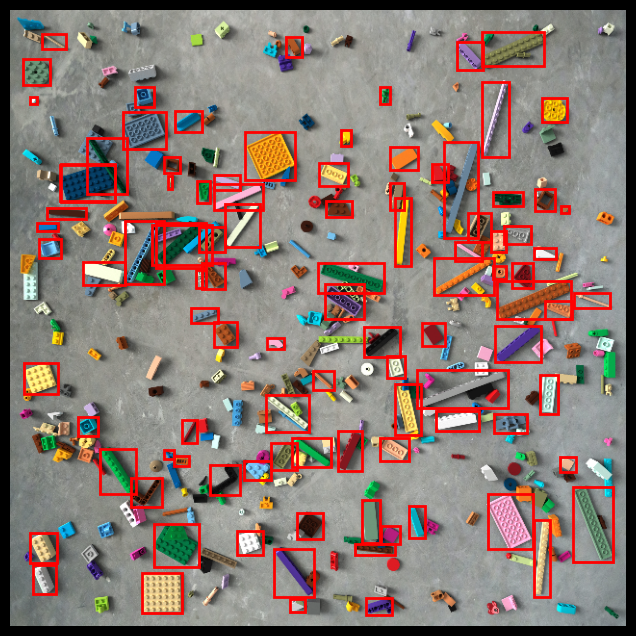

In [16]:
perform_inference('data/val/images/56.png', model, device)